In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Customer_churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#replacing blanks with 0 as tenure is 0 and no total charges are recorded.

In [3]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df["customerID"].duplicated().sum()

np.int64(0)

In [9]:
#converted 0 and 1 value of senior citizen to yes/no to make it easier to identify for others too!

In [10]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


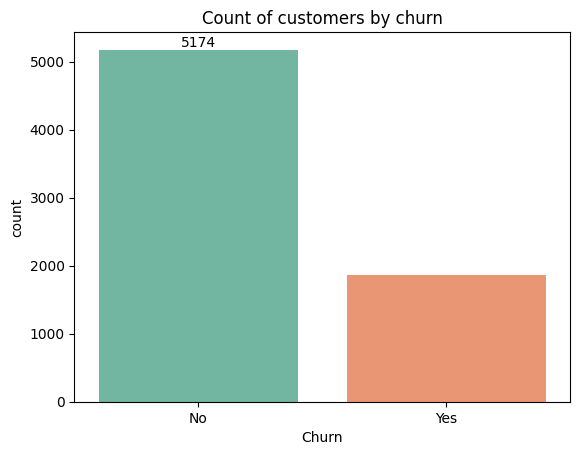

In [80]:
ax = sns.countplot(x="Churn", data=df, hue="Churn", legend=False, palette='Set2')
ax.bar_label(ax.containers[0])
plt.title("Count of customers by churn")
plt.show()

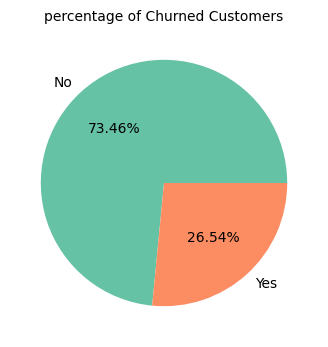

In [79]:
plt.figure(figsize=(4, 4))
gb = df.groupby("Churn").agg({"Churn": "count"})
plt.pie(gb["Churn"], labels=gb.index, autopct="%1.2f%%", colors=['#66c2a5', '#fc8d62'])
plt.title("percentage of Churned Customers", fontsize=10)
plt.show()

In [15]:
#from the given pie chart we can conclude that 26.54% of our customers have churned out.
#Now let's explore the reason behind it.

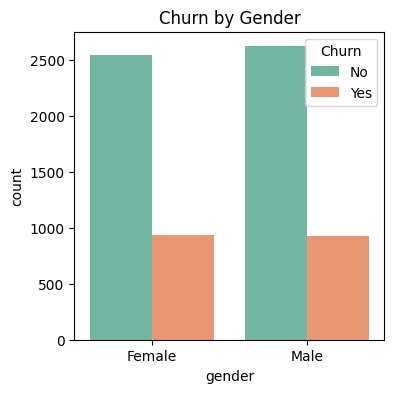

In [78]:
plt.figure(figsize = (4,4))
sns.countplot(x = "gender", data = df, hue = "Churn", palette = 'Set2')
plt.title("Churn by Gender")
plt.show()

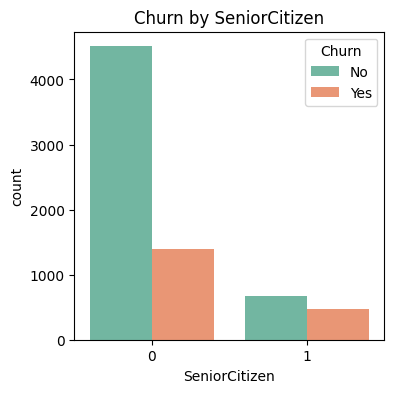

In [77]:
plt.figure(figsize = (4,4))
sns.countplot(x = "SeniorCitizen", data = df, hue = "Churn", palette = 'Set2')
plt.title("Churn by SeniorCitizen")
plt.show()

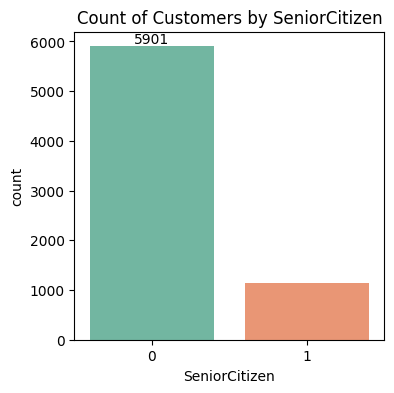

In [75]:
plt.figure(figsize=(4, 4))
ax = sns.countplot(x="SeniorCitizen", data=df, hue="SeniorCitizen", legend=False, palette='Set2')
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by SeniorCitizen")
plt.show()

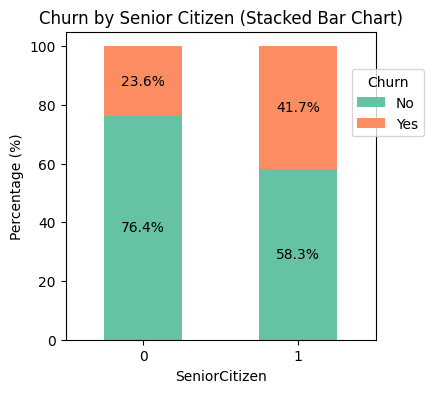

In [72]:
total_counts = df.groupby("SeniorCitizen")['Churn'].value_counts(normalize=True).unstack() * 100

#Plot
fig, ax = plt.subplots(figsize=(4, 4) ) #Adjust figsize for better visualization

#Plot the bars
total_counts.plot(kind="bar", stacked=True, ax=ax, color=['#66c2a5', '#fc8d62'])  #customize colors if desired

#add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')

plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor = (0.9,0.9)) #Customize legend location
plt.show()

In [32]:
#comparative a greated percentage of people in senior citizen category have churned out.

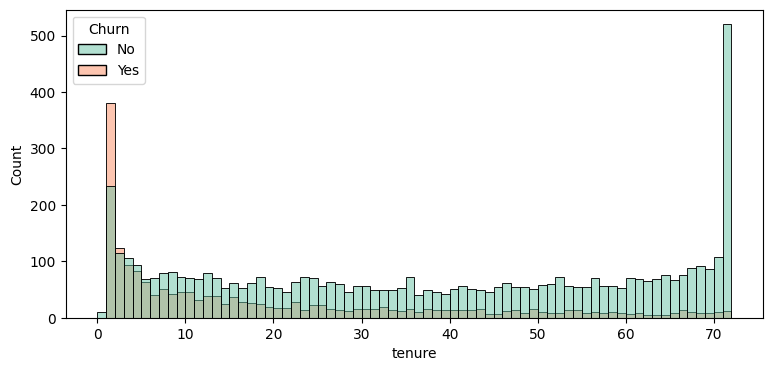

In [62]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn", palette = "Set2")
plt.show()

In [45]:
#people who have used our services for a long time have stayed and people who have used our services #1 or #2 months have churned.


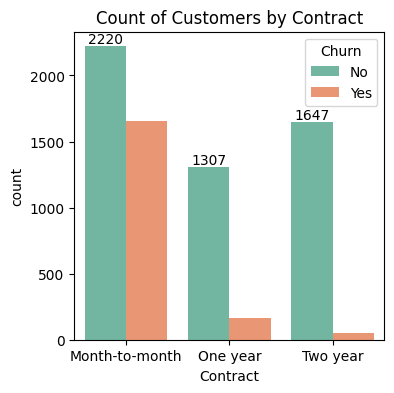

In [61]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract", data = df, hue = "Churn", palette = "Set2")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

In [48]:
#people who have month to month contract are likely to churn then from those who have 1 or 2 years of contract.

In [49]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

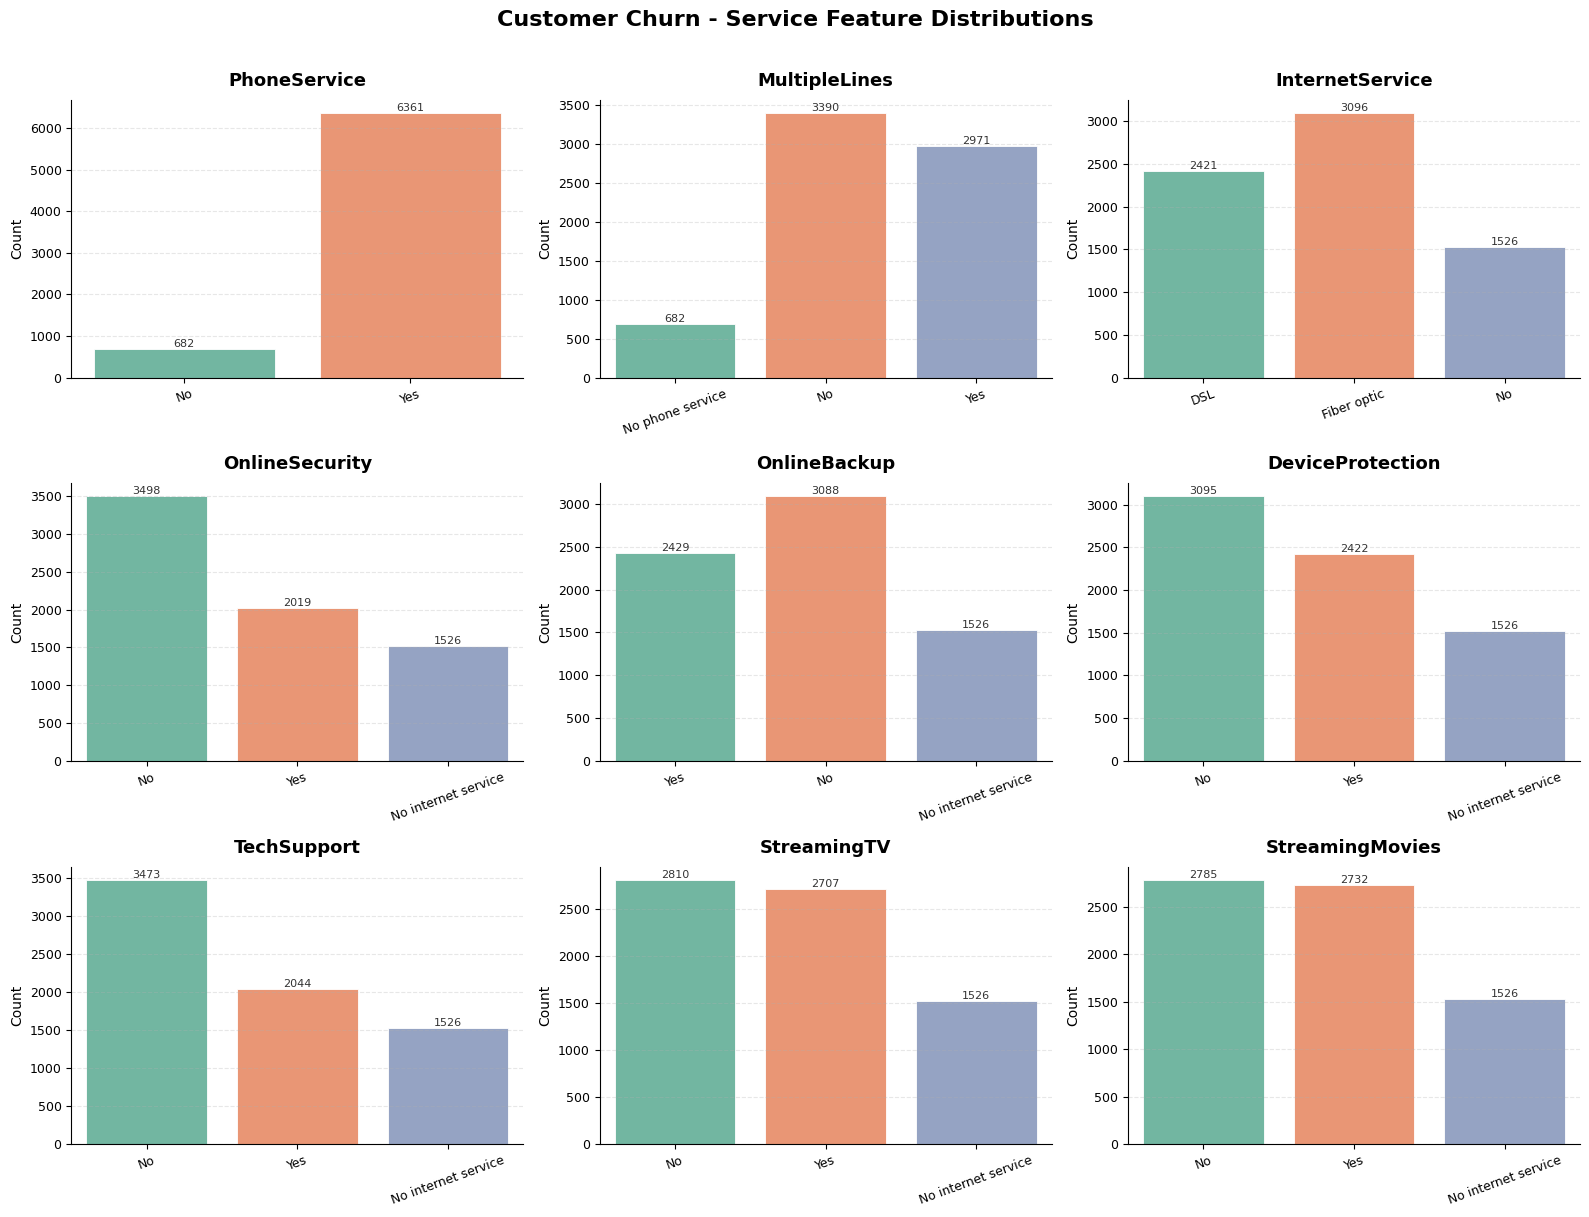

In [53]:
df = pd.read_csv('Customer_churn.csv')

cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, hue=col, legend=False, ax=axes[i], palette='Set2', edgecolor='white', linewidth=0.6)
    axes[i].set_title(col, fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=20, labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8, color='#333333')

fig.suptitle('Customer Churn - Service Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ColumnCategories:
# PhoneService: Yes (6,361) · No (682)
# MultipleLines: No (3,390) · Yes (2,971) · No phone service (682)
# InternetService: Fiber optic (3,096) · DSL (2,421) · No (1,526)
# OnlineSecurity: No (3,498) · Yes (2,019) · No internet service (1,526)
# OnlineBackup: No (3,088) · Yes (2,429) · No internet service (1,526)
# DeviceProtection: No (3,095) · Yes (2,422) · No internet service (1,526)
# TechSupport: No (3,473) · Yes (2,044) · No internet service (1,526)
# StreamingTV: No (2,810) · Yes (2,707) · No internet service (1,526)
# StreamingMovies: No (2,785) · Yes (2,732) · No internet service (1,526)

# Key Takeaways:
# - PhoneService is overwhelmingly subscribed (~90% Yes)
# - Streaming TV & Movies are the most evenly split services, suggesting similar adoption
# - Online Security & Tech Support have the lowest subscription rates among internet users — potential upsell opportunities
# - The 1,526 "No internet service" entries appear consistently across 6 columns, as expected


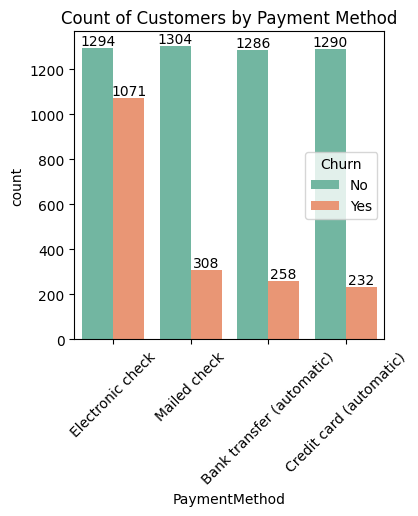

In [60]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn", palette = "Set2")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

In [81]:
#customer is likely to churn when he is using electronic check as a payment method!